### MONTE CARLO BASKET OPTION PRICING
We can use Monte Carlo simulations to compute basket option pricing

Consider a basket option with strike price $K = 60$ and two stocks $S_1(0) = 40$ and $S_2(0) = 30$

We know that the volatility for each stock is given by $\sigma_1 = 15$% and $\sigma_2 = 10$%

Assume for simplicity that both stocks pay no dividends, such that $q_1 = q_2 = 0$ and that the risk neutral drift $r = 7$%

Assume the correlation between the stock returns is $\rho = 0.4$

In [25]:
import matplotlib.pyplot as plt
import numpy as np


def stock_price(S0, r, q, t, sigma, W):
    return S0 * np.exp((r - q - 0.5 * sigma**2)*t + sigma * W)

In [26]:
K = 70
S0_1 = 40
S0_2 = 30
sigma_1 = 0.15
sigma_2 = 0.10
q1, q2 = 0, 0
r = 0.07
corr = 0.4

In [27]:
N = 100_000
Z = np.random.normal(loc=0, scale=1, size=(2, N))
Z1 = Z[0, :]
Z2 = Z[1, :]

X1 = Z1.copy()
X2 = corr * Z1 + np.sqrt(1 - corr**2) * Z2

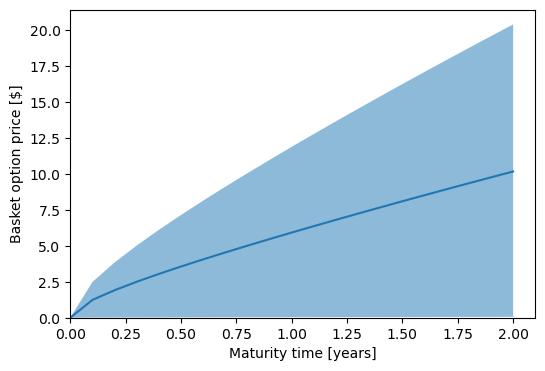

In [28]:
times = np.linspace(0, 2, 21)

mean_basket_price = []
mean_basket_price_error = []
conf_level_low = []
conf_level_high = []


for t in times:
    W1 = X1 * np.sqrt(t)
    W2 = X2 * np.sqrt(t)

    S1_t = stock_price(S0_1, r, q1, t, sigma_1, W1)
    S2_t = stock_price(S0_2, r, q2, t, sigma_2, W2)

    payoff_t = np.maximum(S1_t + S2_t - K, 0)     # Value at maturity
    discounted_payoff_t = np.exp(-r*t) * payoff_t # Present value
    
    price = np.mean(discounted_payoff_t)
    price_error = np.std(discounted_payoff_t, ddof=1) / np.sqrt(N)
    
    mean_basket_price.append(price)             # Mean price at t=0
    mean_basket_price_error.append(price_error) # Standard error of the mean
    conf_level_low.append(price - 1.96 * price_error)
    conf_level_high.append(price + 1.96 * price_error)

mean_basket_price = np.array(mean_basket_price)
mean_basket_price_error = np.array(mean_basket_price_error)
conf_level_low = np.array(conf_level_low)
conf_level_high = np.array(conf_level_high)


fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(times, mean_basket_price)
ax.fill_between(times, mean_basket_price - conf_level_low, mean_basket_price + conf_level_high, alpha=0.5)
ax.set_xlabel('Maturity time [years]')
ax.set_ylabel('Basket option price [$]')

ax.set_xlim(0,)
ax.set_ylim(0,)
plt.show()

### Changes with number of simulations

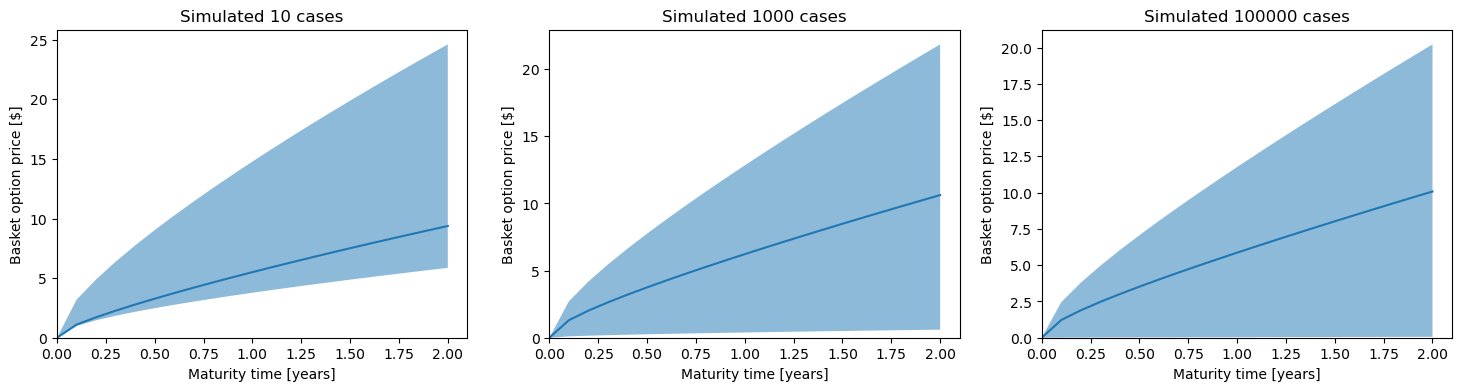

In [31]:
K = 70
S0_1 = 40
S0_2 = 30
sigma_1 = 0.15
sigma_2 = 0.10
q1, q2 = 0, 0
r = 0.07
corr = 0.4

params = [10, 1_000, 100_000]

fig, ax = plt.subplots(1, len(params), figsize=(6*len(params), 4))

for i,N in enumerate(params):
    Z = np.random.normal(loc=0, scale=1, size=(2, N))
    Z1 = Z[0, :]
    Z2 = Z[1, :]

    X1 = Z1.copy()
    X2 = corr * Z1 + np.sqrt(1 - corr**2) * Z2


    times = np.linspace(0, 2, 21)

    mean_basket_price = []
    mean_basket_price_error = []
    conf_level_low = []
    conf_level_high = []


    for t in times:
        W1 = X1 * np.sqrt(t)
        W2 = X2 * np.sqrt(t)

        S1_t = stock_price(S0_1, r, q1, t, sigma_1, W1)
        S2_t = stock_price(S0_2, r, q2, t, sigma_2, W2)

        payoff_t = np.maximum(S1_t + S2_t - K, 0)     # Value at maturity
        discounted_payoff_t = np.exp(-r*t) * payoff_t # Present value
        
        price = np.mean(discounted_payoff_t)
        price_error = np.std(discounted_payoff_t, ddof=1) / np.sqrt(N)
        
        mean_basket_price.append(price)             # Mean price at t=0
        mean_basket_price_error.append(price_error) # Standard error of the mean
        conf_level_low.append(price - 1.96 * price_error)
        conf_level_high.append(price + 1.96 * price_error)

    mean_basket_price = np.array(mean_basket_price)
    mean_basket_price_error = np.array(mean_basket_price_error)
    conf_level_low = np.array(conf_level_low)
    conf_level_high = np.array(conf_level_high)


    ax[i].set_title(f'Simulated {N} cases')
    ax[i].plot(times, mean_basket_price)
    ax[i].fill_between(times, mean_basket_price - conf_level_low, mean_basket_price + conf_level_high, alpha=0.5)
    ax[i].set_xlabel('Maturity time [years]')
    ax[i].set_ylabel('Basket option price [$]')
    ax[i].set_xlim(0,)
    ax[i].set_ylim(0,)
    
plt.show()

### Changes with multiple strike prices

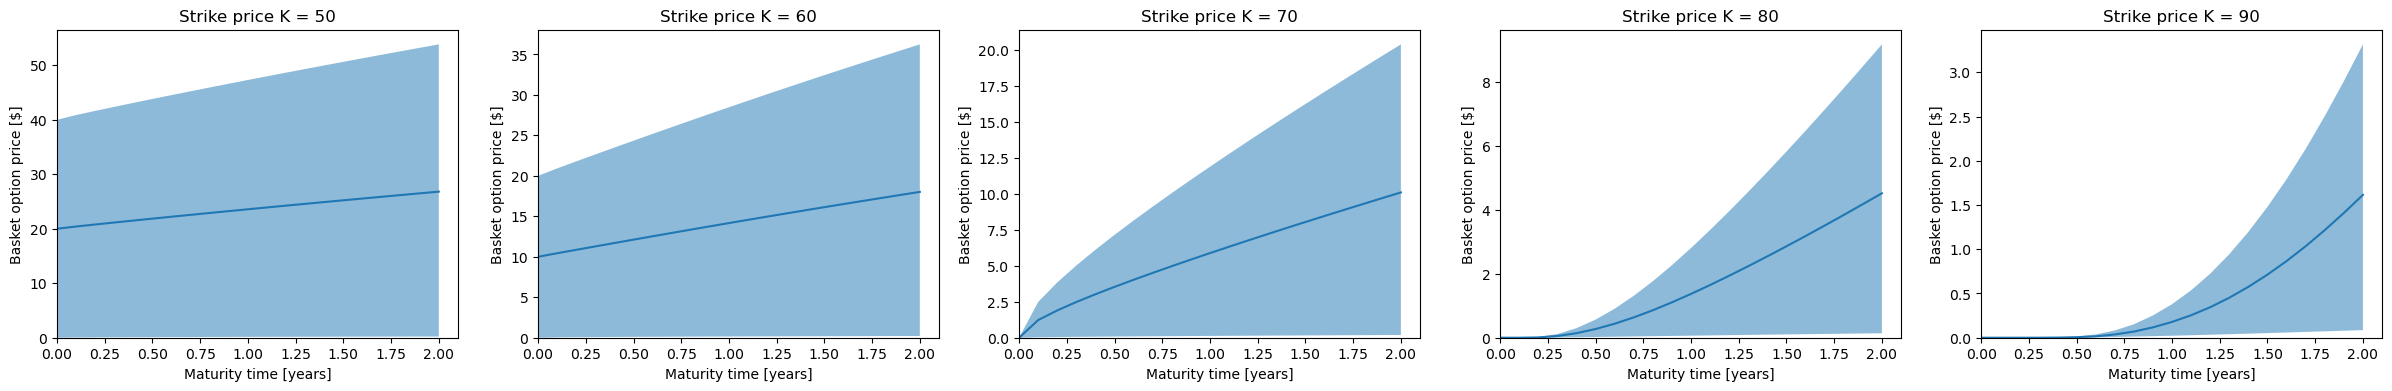

In [32]:
N = 10_000
S0_1 = 40
S0_2 = 30
sigma_1 = 0.15
sigma_2 = 0.10
q1, q2 = 0, 0
r = 0.07
corr = 0.4

params = [50, 60, 70, 80, 90]

fig, ax = plt.subplots(1, len(params), figsize=(6*len(params), 4))

for i,K in enumerate(params):
    Z = np.random.normal(loc=0, scale=1, size=(2, N))
    Z1 = Z[0, :]
    Z2 = Z[1, :]

    X1 = Z1.copy()
    X2 = corr * Z1 + np.sqrt(1 - corr**2) * Z2


    times = np.linspace(0, 2, 21)

    mean_basket_price = []
    mean_basket_price_error = []
    conf_level_low = []
    conf_level_high = []


    for t in times:
        W1 = X1 * np.sqrt(t)
        W2 = X2 * np.sqrt(t)

        S1_t = stock_price(S0_1, r, q1, t, sigma_1, W1)
        S2_t = stock_price(S0_2, r, q2, t, sigma_2, W2)

        payoff_t = np.maximum(S1_t + S2_t - K, 0)     # Value at maturity
        discounted_payoff_t = np.exp(-r*t) * payoff_t # Present value
        
        price = np.mean(discounted_payoff_t)
        price_error = np.std(discounted_payoff_t, ddof=1) / np.sqrt(N)
        
        mean_basket_price.append(price)             # Mean price at t=0
        mean_basket_price_error.append(price_error) # Standard error of the mean
        conf_level_low.append(price - 1.96 * price_error)
        conf_level_high.append(price + 1.96 * price_error)

    mean_basket_price = np.array(mean_basket_price)
    mean_basket_price_error = np.array(mean_basket_price_error)
    conf_level_low = np.array(conf_level_low)
    conf_level_high = np.array(conf_level_high)


    ax[i].set_title(f'Strike price K = {K}')
    ax[i].plot(times, mean_basket_price)
    ax[i].fill_between(times, mean_basket_price - conf_level_low, mean_basket_price + conf_level_high, alpha=0.5)
    ax[i].set_xlabel('Maturity time [years]')
    ax[i].set_ylabel('Basket option price [$]')
    ax[i].set_xlim(0,)
    ax[i].set_ylim(0,)
    
plt.show()

### Changes with multiple correlations

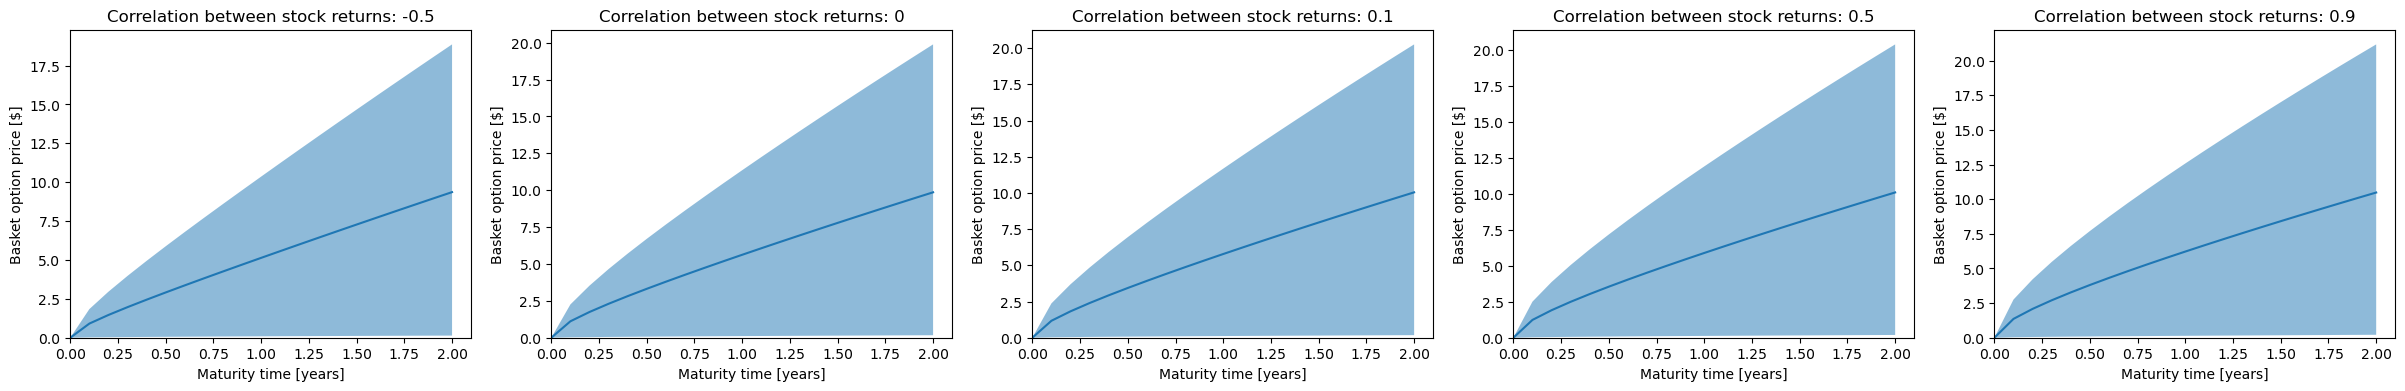

In [33]:
K = 70
N = 10_000
S0_1 = 40
S0_2 = 30
sigma_1 = 0.15
sigma_2 = 0.10
q1, q2 = 0, 0
r = 0.07

params = [-0.5, 0, 0.1, 0.5, 0.9]

fig, ax = plt.subplots(1, len(params), figsize=(6*len(params), 4))

for i,corr in enumerate(params):
    Z = np.random.normal(loc=0, scale=1, size=(2, N))
    Z1 = Z[0, :]
    Z2 = Z[1, :]

    X1 = Z1.copy()
    X2 = corr * Z1 + np.sqrt(1 - corr**2) * Z2


    times = np.linspace(0, 2, 21)

    mean_basket_price = []
    mean_basket_price_error = []
    conf_level_low = []
    conf_level_high = []


    for t in times:
        W1 = X1 * np.sqrt(t)
        W2 = X2 * np.sqrt(t)

        S1_t = stock_price(S0_1, r, q1, t, sigma_1, W1)
        S2_t = stock_price(S0_2, r, q2, t, sigma_2, W2)

        payoff_t = np.maximum(S1_t + S2_t - K, 0)     # Value at maturity
        discounted_payoff_t = np.exp(-r*t) * payoff_t # Present value
        
        price = np.mean(discounted_payoff_t)
        price_error = np.std(discounted_payoff_t, ddof=1) / np.sqrt(N)
        
        mean_basket_price.append(price)             # Mean price at t=0
        mean_basket_price_error.append(price_error) # Standard error of the mean
        conf_level_low.append(price - 1.96 * price_error)
        conf_level_high.append(price + 1.96 * price_error)

    mean_basket_price = np.array(mean_basket_price)
    mean_basket_price_error = np.array(mean_basket_price_error)
    conf_level_low = np.array(conf_level_low)
    conf_level_high = np.array(conf_level_high)


    ax[i].set_title(f'Correlation between stock returns: {corr}')
    ax[i].plot(times, mean_basket_price)
    ax[i].fill_between(times, mean_basket_price - conf_level_low, mean_basket_price + conf_level_high, alpha=0.5)
    ax[i].set_xlabel('Maturity time [years]')
    ax[i].set_ylabel('Basket option price [$]')
    ax[i].set_xlim(0,)
    ax[i].set_ylim(0,)
    
plt.show()

### Changes with stock volatilities

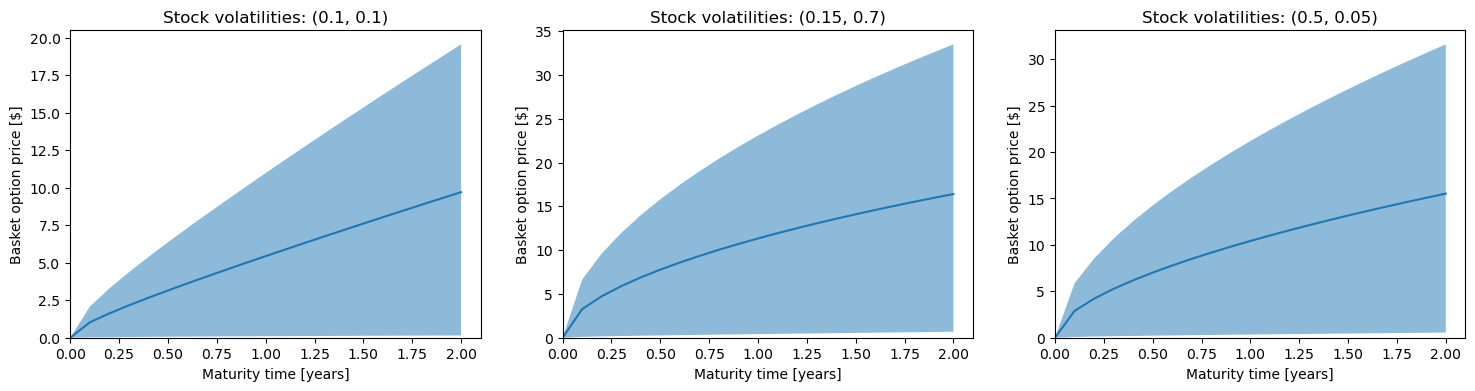

In [34]:
K = 70
N = 10_000
S0_1 = 40
S0_2 = 30
q1, q2 = 0, 0
r = 0.07
corr = 0.4

params = [(0.10, 0.10), (0.15, 0.7), (0.5, 0.05)]

fig, ax = plt.subplots(1, len(params), figsize=(6*len(params), 4))

for i,vol in enumerate(params):
    sigma_1, sigma_2 = vol

    Z = np.random.normal(loc=0, scale=1, size=(2, N))
    Z1 = Z[0, :]
    Z2 = Z[1, :]

    X1 = Z1.copy()
    X2 = corr * Z1 + np.sqrt(1 - corr**2) * Z2


    times = np.linspace(0, 2, 21)

    mean_basket_price = []
    mean_basket_price_error = []
    conf_level_low = []
    conf_level_high = []


    for t in times:
        W1 = X1 * np.sqrt(t)
        W2 = X2 * np.sqrt(t)

        S1_t = stock_price(S0_1, r, q1, t, sigma_1, W1)
        S2_t = stock_price(S0_2, r, q2, t, sigma_2, W2)

        payoff_t = np.maximum(S1_t + S2_t - K, 0)     # Value at maturity
        discounted_payoff_t = np.exp(-r*t) * payoff_t # Present value
        
        price = np.mean(discounted_payoff_t)
        price_error = np.std(discounted_payoff_t, ddof=1) / np.sqrt(N)
        
        mean_basket_price.append(price)             # Mean price at t=0
        mean_basket_price_error.append(price_error) # Standard error of the mean
        conf_level_low.append(price - 1.96 * price_error)
        conf_level_high.append(price + 1.96 * price_error)

    mean_basket_price = np.array(mean_basket_price)
    mean_basket_price_error = np.array(mean_basket_price_error)
    conf_level_low = np.array(conf_level_low)
    conf_level_high = np.array(conf_level_high)


    ax[i].set_title(f'Stock volatilities: {vol}')
    ax[i].plot(times, mean_basket_price)
    ax[i].fill_between(times, mean_basket_price - conf_level_low, mean_basket_price + conf_level_high, alpha=0.5)
    ax[i].set_xlabel('Maturity time [years]')
    ax[i].set_ylabel('Basket option price [$]')
    ax[i].set_xlim(0,)
    ax[i].set_ylim(0,)
    
plt.show()

### Changes with multiple risk free returns

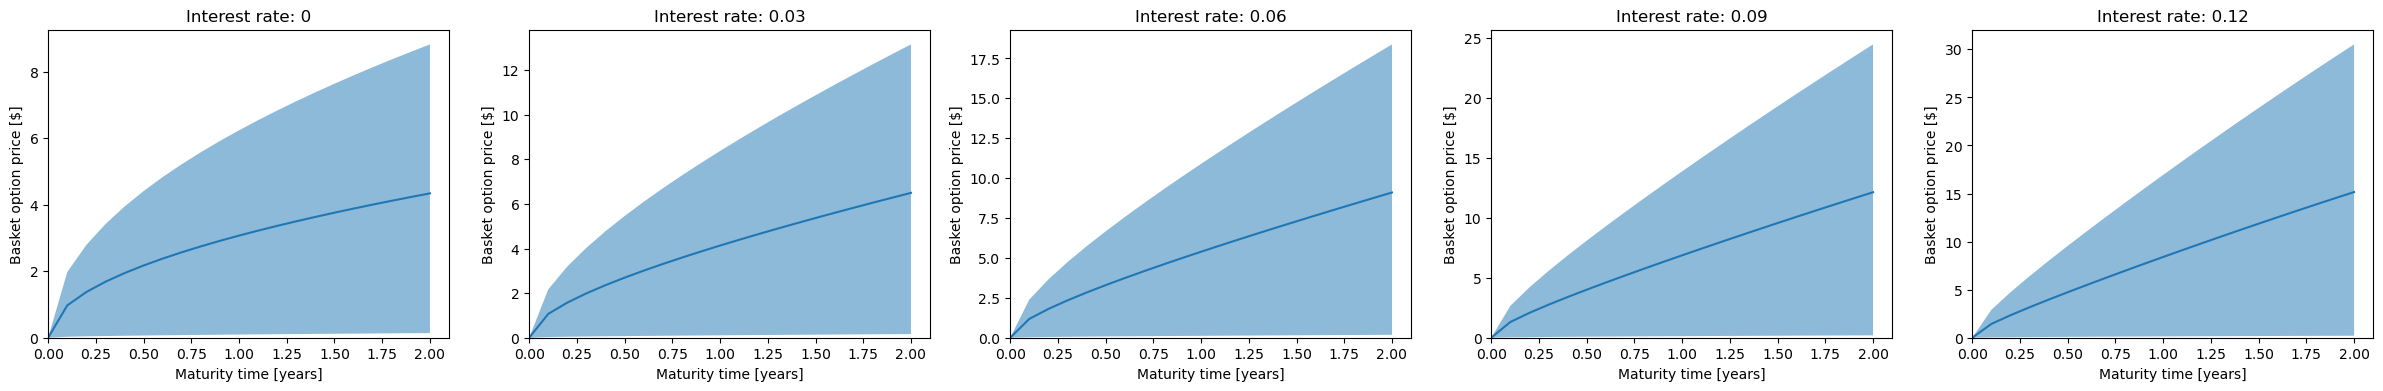

In [35]:
K = 70
N = 10_000
S0_1 = 40
S0_2 = 30
sigma_1 = 0.15
sigma_2 = 0.10
q1, q2 = 0, 0
corr = 0.4

params = [0, 0.03, 0.06, 0.09, 0.12]

fig, ax = plt.subplots(1, len(params), figsize=(6*len(params), 4))

for i,r in enumerate(params):
    Z = np.random.normal(loc=0, scale=1, size=(2, N))
    Z1 = Z[0, :]
    Z2 = Z[1, :]

    X1 = Z1.copy()
    X2 = corr * Z1 + np.sqrt(1 - corr**2) * Z2


    times = np.linspace(0, 2, 21)

    mean_basket_price = []
    mean_basket_price_error = []
    conf_level_low = []
    conf_level_high = []


    for t in times:
        W1 = X1 * np.sqrt(t)
        W2 = X2 * np.sqrt(t)

        S1_t = stock_price(S0_1, r, q1, t, sigma_1, W1)
        S2_t = stock_price(S0_2, r, q2, t, sigma_2, W2)

        payoff_t = np.maximum(S1_t + S2_t - K, 0)     # Value at maturity
        discounted_payoff_t = np.exp(-r*t) * payoff_t # Present value
        
        price = np.mean(discounted_payoff_t)
        price_error = np.std(discounted_payoff_t, ddof=1) / np.sqrt(N)
        
        mean_basket_price.append(price)             # Mean price at t=0
        mean_basket_price_error.append(price_error) # Standard error of the mean
        conf_level_low.append(price - 1.96 * price_error)
        conf_level_high.append(price + 1.96 * price_error)

    mean_basket_price = np.array(mean_basket_price)
    mean_basket_price_error = np.array(mean_basket_price_error)
    conf_level_low = np.array(conf_level_low)
    conf_level_high = np.array(conf_level_high)


    ax[i].set_title(f'Interest rate: {r}')
    ax[i].plot(times, mean_basket_price)
    ax[i].fill_between(times, mean_basket_price - conf_level_low, mean_basket_price + conf_level_high, alpha=0.5)
    ax[i].set_xlabel('Maturity time [years]')
    ax[i].set_ylabel('Basket option price [$]')
    ax[i].set_xlim(0,)
    ax[i].set_ylim(0,)
    
plt.show()